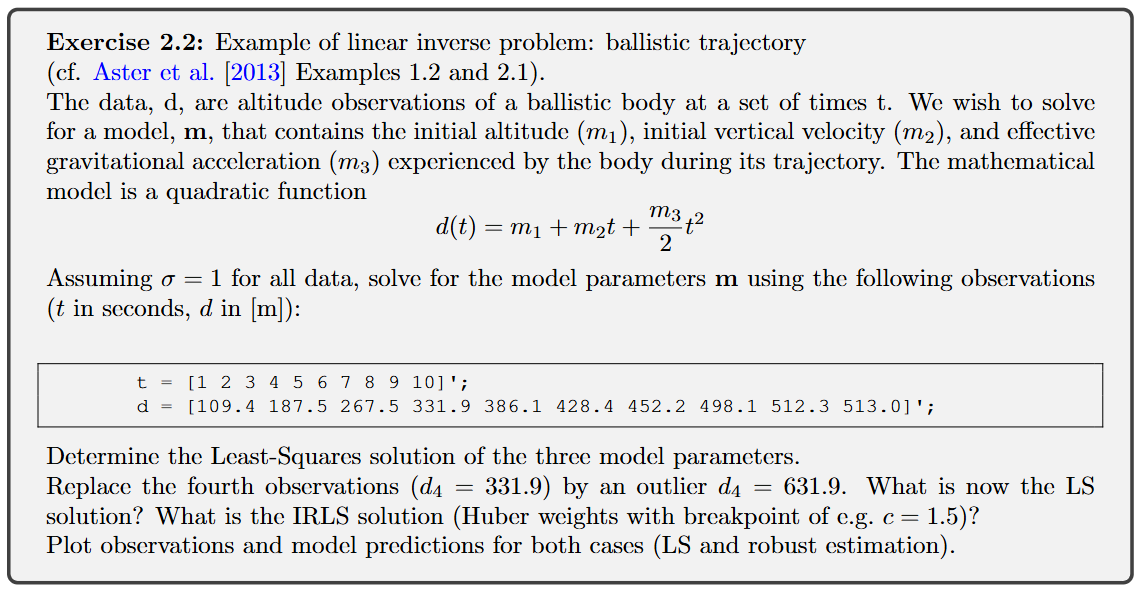

Recall

$$
\hat{m} = (G^T W G)^{-1} G^T W d
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
t = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
d = np.array([109.4, 187.5, 267.5, 331.9, 386.1, 428.4, 452.2, 498.1, 512.3, 513.0])
sigma = 1

In [3]:
# Construct design matrix G:
G = np.column_stack((np.ones_like(t), t, 1/2 * t**2))
W = np.eye(len(t))

m_hat_ls = np.linalg.inv(G.T @ W @ G) @ G.T @ W @ d
print(m_hat_ls)

[16.40833333 96.97128788 -9.40833333]


In [4]:
d2 = d.copy()
d2[3] = 631.9

m2_hat_ls = np.linalg.inv(G.T @ G) @ G.T @ d2
print(m2_hat_ls)

[  1.40833333 129.01674242 -16.22651515]


In [5]:
def huber_weights(residuals, c):
    return np.minimum(c / np.abs(residuals), np.ones_like(residuals))


In [6]:
def do_irls(G, d, W_init, c: float = 1.5, n_iter: int = 100):
    W = W_init
    m = np.zeros(G.shape[1])
    for _ in range(n_iter):
        m = np.linalg.solve(G.T @ W @ G, G.T @ W @ d)

        prediction = G @ m
        residuals = (d - prediction) / sigma
        weights = huber_weights(residuals, c)

        W = np.diag(weights)

    return m

m_irls = do_irls(G, d, W_init=np.eye(G.shape[0]))
m2_irls = do_irls(G, d2, W_init=np.eye(G.shape[0]))

print(G.shape)

(10, 3)


In [7]:
# # Iteratively Reweighted Least Squares (IRLS):
# m_irls = m_hat_ls.copy()
# N_iter = 25

# m_irls = np.zeros_like(m_hat_ls)
# weights = np.ones_like(d)

# print(f"{m_irls=}")
# for _ in range(N_iter):
#     predicted = G @ m_irls
#     residuals = d - predicted

#     # Update weights
#     weights = huber_weights(residuals, c=1.5)

#     W_irls = np.diag(weights)
#     m_irls = np.linalg.inv(G.T @ W_irls @ G) @ G.T @ W_irls @ d2

# print(m_irls)

Text(0.5, 1.0, 'Exercise 2.2')

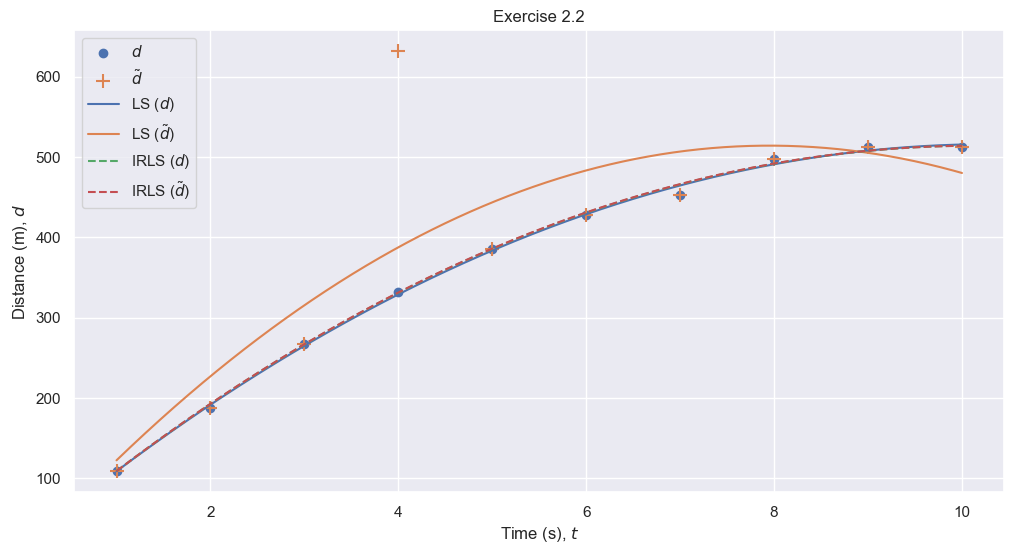

In [8]:
plt.figure(figsize=(12, 6))

plt.scatter(x=t, y=d, marker="o", label="$d$")
plt.scatter(x=t, y=d2, marker="+", s=100, label="$\\tilde{d}$")

# Fine resolution for plotting model predictions, interpolation of t
t_interp = np.linspace(t.min(), t.max(), 1000)
G_interp = np.column_stack((np.ones_like(t_interp), t_interp, 1/2 * t_interp**2))

# Model predictions
d_pred_ls = G_interp @ m_hat_ls
d2_pred_ls = G_interp @ m2_hat_ls
d_pred_irls = G_interp @ m_irls
d2_pred_irls = G_interp @ m2_irls

plt.plot(t_interp, d_pred_ls, label="LS ($d$)")
plt.plot(t_interp, d2_pred_ls, label="LS ($\\tilde{d}$)")
plt.plot(t_interp, d_pred_irls, ls="--", label="IRLS ($d$)")
plt.plot(t_interp, d2_pred_irls, ls="--", label="IRLS ($\\tilde{d}$)")

plt.legend()
plt.xlabel("Time (s), $t$")
plt.ylabel("Distance (m), $d$")
plt.title("Exercise 2.2")